In [12]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, roc_curve, confusion_matrix,
    balanced_accuracy_score, average_precision_score, auc as sk_auc
)

plt.style.use('ggplot')

colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)

In [13]:
def interpolate(p1_fpr, p1_tpr, p2_fpr, p2_tpr, x):
    """
    Linear interpolation of TPR at FPR = x between points (p1_fpr, p1_tpr) and (p2_fpr, p2_tpr).
    """
    slope = (p2_tpr - p1_tpr) / (p2_fpr - p1_fpr)
    return p1_tpr + slope * (x - p1_fpr)


def tpr_for_fpr(fprsample, fpr_arr, tpr_arr):
    """
    Implements Algorithm 3's helper that finds / interpolates TPR at a specific FPR.
    Assumes fpr_arr is sorted ascending and has the same length as tpr_arr.
    """
    # Locate the rightmost point whose FPR ≤ fprsample
    i = np.searchsorted(fpr_arr, fprsample, side="right") - 1
    # Edge cases: before first point or exactly at end
    if i < 0:                     # fprsample < smallest FPR in curve
        return tpr_arr[0]
    if fpr_arr[i] == fprsample or i == len(fpr_arr) - 1:
        return tpr_arr[i]
    # Otherwise interpolate between point i and i+1
    return interpolate(fpr_arr[i], tpr_arr[i],
                       fpr_arr[i + 1], tpr_arr[i + 1],
                       fprsample)

def vertical_avg_roc(roc_data):
    '''
    ROC curve averaging function.
    Takes a list of ROC data (each element is a tuple of fpr, tpr, thresholds)
    all the fpr values are concatenated and sorted, then the fpr of each curve is sampled
    at these points, and then averaged
    :param roc_data: list of tuples (fpr, tpr, thresholds)
    :return: tuple (fpr, tpr) of the averaged ROC curve 
    '''
    fprs = []
    tprs = []
    for fpr, tpr, _ in roc_data:
        fprs.append(fpr)
        tprs.append(tpr)
    fprs = np.concatenate(fprs)

    # make sure fprs ends with 1 and starts with 0
    if fprs[0] != 0:
        fprs = np.insert(fprs, 0, 0)
    if fprs[-1] != 1:
        fprs = np.append(fprs, 1)
    
    fprs = np.sort(np.unique(fprs))
    tprs=np.zeros(shape=(len(roc_data),len(fprs)))

    for i, fpr in enumerate(fprs):
        for curve_idx,(fpr_arr, tpr_arr, _) in enumerate(roc_data):
            tprs[curve_idx, i] = tpr_for_fpr(fpr, fpr_arr, tpr_arr)
    tpr = np.mean(tprs, axis=0)
    return fprs, tpr




In [14]:
DATADIR = '/space/gzanardini/emc/emc_singleset_final/'

feat_types=['spectral','cwt','dwt','mst','sst','cc','plv','gcc','gplv','utm']
featnames={'spectral':'S',
           'cwt':'CWT',
           'dwt':'DWT',
           'mst':'mST',
              'sst':'sST',
              'cc':'CC',
                'plv':'PLV',
                'gcc':'GCC',
                'gplv':'GPLV',
                'utm':'UTM'}

def get_predictions_files(datadir, montage, featuretype, length, combiner, seeds, epochs=False):


    if not epochs:
        files = [file for file in os.listdir(datadir) if file.startswith(f'predictions_{montage}_{featuretype}_{length}s_{combiner}_run_') and file.endswith('.csv')]
        files = [file for file in files if any(f'_seed_{seed}' in file for seed in seeds)]

    else:
        files = [file for file in os.listdir(datadir) if file.startswith(f'{featuretype}_{montage}_{length}s_{combiner}_run_') and file.endswith('.csv')] 
       #match the seeds in the file names 
        files = [file for file in files if any( file.split('_')[-1][:-4] == str(seed) for seed in seeds)]

    return files

In [15]:
def compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6):
    """
    Compute the slope of the ROC threshold line for a given posterior probability.

    Parameters:
    - n_epileptic: int, number of epileptic cases in dataset
    - n_healthy: int, number of healthy subjects in dataset
    - posterior_threshold: float, required posterior probability after positive test (default=0.6)

    Returns:
    - slope: float, multiplier for FPR to get required sensitivity (ROC space)
    """
    # Prior probabilities from data
    p_epileptic = n_epileptic / (n_epileptic + n_healthy)
    p_healthy = 1 - p_epileptic

    # Calculate slope in ROC space
    slope = (posterior_threshold * p_healthy) / (p_epileptic * (1 - posterior_threshold))

    return slope

In [16]:
def calculate_bac(labels, scores, sens_thresh):
    """
    Calculate balanced accuracy with a sensitivity threshold.
    Returns: (bac, fpr, tpr, thresholds)
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    threshold_sensitivity = thresholds[np.where(tpr >= sens_thresh)[0][0]]
    adjusted_predictions = (scores >= threshold_sensitivity).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, adjusted_predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    bac = ((sensitivity + specificity) / 2)
    return bac, fpr, tpr, thresholds

In [17]:
'''SPECTRAL	Cz	10	std	(3475,4132,3731,4531,3577)
UTM	Bipolar	20	std	(3396,1605,3926,2890,622)
CC	Car	1	std	(4374,2216,4506,1672,3092)
GCC	Car	60	median	(189,3838,902,1822,1600)
PLV	Laplacian	60	kurt	(2483,129,2841,3314,4579)
GPLV	Laplacian	2	std	(602,3569,1889,858,778)
CWT	Bipolar	2	median	(226,3382,1694,446,293)
DWT	Laplacian	10	median	(1571,2618,1098,2591,3115)
SST	Car	10	median	(2126,146,3804,1702,4429)
MST	bipolar 	60	median	(4579,869,754,2291,328)'''


best_runs_whole={
    'spectral' : ('Cz', 10, 'std', (3475, 4132, 3731, 4531, 3577)),
    'utm' : ('BipolarDB', 20, 'std', (3396, 1605, 3926, 2890, 622)),
    'cc' : ('CAR', 1, 'std', (4374, 2216, 4506, 1672, 3092)),
    'gcc' : ('CAR', 60, 'median', (189, 3838, 902, 1822, 1600)),
    'plv' : ('Laplacian', 60, 'kurt', (2483, 129, 2841, 3314, 4579)),
    'gplv' : ('Laplacian', 2, 'std', (602, 3569, 1889, 858, 778)),
    'cwt' : ('BipolarDB', 2, 'median', (226, 3382, 1694, 446, 293)),
    'dwt' : ('Laplacian', 10, 'median', (1571, 2618, 1098, 2591, 3115)),
    'sst' : ('CAR', 10, 'median', (2126, 146, 3804, 1702, 4429)),
    'mst' : ('BipolarDB', 60, 'median', (4579, 869, 754, 2291, 328))
}

In [18]:
def compute_all_metrics(y_true, y_pred, y_scores):
    """
    Compute all metrics used in ENSEMBLES.ipynb
    """
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_scores)
    bac = balanced_accuracy_score(y_true, y_pred)
    bac80, fpr, tpr, thresholds = calculate_bac(y_true, y_scores, 0.80)
    p, r, t = precision_recall_curve(y_true, y_scores)
    auprc = sk_auc(r, p)
    ap = average_precision_score(y_true, y_scores)
    
    return {
        'accuracy': accuracy,
        'bac': bac,
        'bac80': bac80,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'auc': auc,
        'auprc': auprc,
        'AP': ap
    }

def create_metrics_summary_table(feat_types, best_runs, datadir, epochs=False):
    """
    Create a comprehensive metrics summary table for all feature types
    """
    df_summary = pd.DataFrame(columns=[
        'feature_type', 'accuracy', 'bac', 'bac80', 'f1_score',
        'precision', 'recall', 'auc', 'auprc', 'AP'
    ])
    
    for feature_type in feat_types:
        montage, length, combiner, seeds = best_runs[feature_type]
        predictions_files = get_predictions_files(datadir, montage, feature_type, length, combiner, seeds, epochs=epochs)
        
        # Collect metrics for each run
        run_metrics = []
        for file in predictions_files:
            df_file = pd.read_csv(os.path.join(datadir, file))
            if epochs:
                y_true = df_file['y_true'].values
                y_scores = df_file['y_prob'].values
            else:
                y_true = df_file['y_tests'].values
                y_scores = df_file['y_scores'].values
            
            # Use threshold 0.5 for binary predictions
            y_pred = (y_scores >= 0.5).astype(int)
            
            metrics_dict = compute_all_metrics(y_true, y_pred, y_scores)
            metrics_dict['feature_type'] = feature_type
            run_metrics.append(metrics_dict)
        
        # Add all runs to summary
        for metrics_dict in run_metrics:
            df_summary = pd.concat([df_summary, pd.DataFrame([metrics_dict])], ignore_index=True)
    
    return df_summary

Slope for threshold 0.6: 3.79


<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_573703/3099764159.py:17: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')


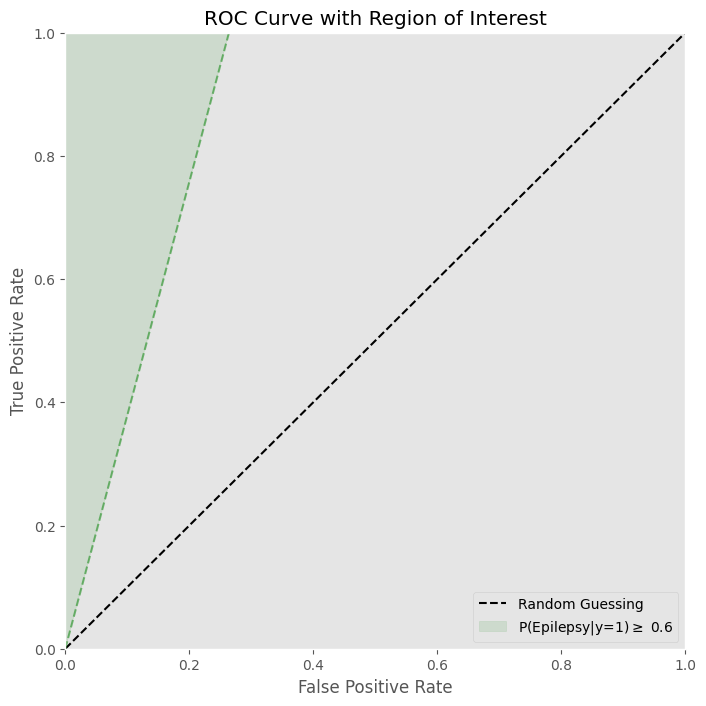

In [22]:
#make an empty roc plot with the diagonal line and region of interest highlighted
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label
='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Region of Interest')

# Highlight region of interest (FPR < 0.2, TPR > 0.8)

print(f'Slope for threshold 0.6: {slope:.2f}')
# plot a line with this slope, limit the y axis to [0, 1]
plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
#fill above the line
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')
plt.legend()
plt.grid()
plt.show()


<>:39: SyntaxWarning: invalid escape sequence '\g'
<>:39: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_573703/1973471997.py:39: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')


spectral Pooled AUC: 0.67
cwt Pooled AUC: 0.67
dwt Pooled AUC: 0.70
mst Pooled AUC: 0.63
sst Pooled AUC: 0.71
cc Pooled AUC: 0.72
plv Pooled AUC: 0.75
gcc Pooled AUC: 0.67
gplv Pooled AUC: 0.70
utm Pooled AUC: 0.68
Slope for threshold 0.6: 3.79


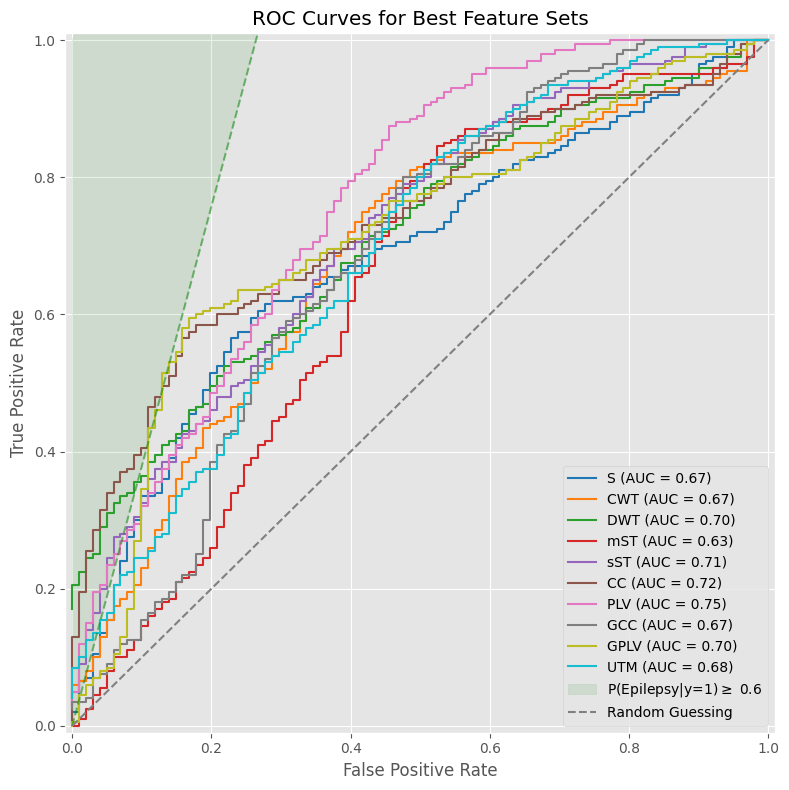


COMPREHENSIVE METRICS FOR WHOLE SEGMENTS
Feature      ACCURACY           BAC         BAC80      F1_SCORE     PRECISION        RECALL           AUC         AUPRC            AP
      S 0.723 ± 0.009 0.593 ± 0.014 0.615 ± 0.030 0.372 ± 0.033 0.523 ± 0.031 0.290 ± 0.038 0.671 ± 0.020 0.432 ± 0.022 0.447 ± 0.020
    CWT 0.701 ± 0.013 0.584 ± 0.016 0.674 ± 0.023 0.374 ± 0.029 0.460 ± 0.032 0.315 ± 0.029 0.669 ± 0.014 0.435 ± 0.019 0.446 ± 0.017
    DWT 0.733 ± 0.016 0.627 ± 0.016 0.632 ± 0.016 0.447 ± 0.026 0.544 ± 0.040 0.380 ± 0.021 0.698 ± 0.013 0.559 ± 0.035 0.565 ± 0.033
    mST 0.661 ± 0.020 0.520 ± 0.019 0.651 ± 0.018 0.246 ± 0.029 0.335 ± 0.048 0.195 ± 0.021 0.632 ± 0.016 0.343 ± 0.008 0.357 ± 0.009
    sST 0.732 ± 0.013 0.605 ± 0.008 0.657 ± 0.020 0.396 ± 0.012 0.552 ± 0.046 0.310 ± 0.014 0.704 ± 0.023 0.463 ± 0.028 0.479 ± 0.030
     CC 0.760 ± 0.006 0.656 ± 0.008 0.633 ± 0.014 0.495 ± 0.015 0.616 ± 0.020 0.415 ± 0.022 0.721 ± 0.015 0.537 ± 0.035 0.552 ± 0.035
    PLV 0.732 ± 0.01

In [21]:
plt.figure(figsize=(8,8))

for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_whole[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=False)

    flag = False
    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
        y_true = df['y_tests'].values
        y_pred = df['y_scores'].values

        if flag == False:# count healthy and epleptic in y true
            n_epileptic = np.sum(y_true)
            n_healthy = len(y_true) - n_epileptic
            flag = True
        # Compute ROC curve
        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_tests'].values).astype(np.float64)
    y_pred = np.array(preds['y_scores'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)
    plt.step(fpr, tpr, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}')

slope = compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6)

print(f'Slope for threshold 0.6: {slope:.2f}')
# plot a line with this slope, limit the y axis to [0, 1]
plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
#fill above the line
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')
plt.title('ROC Curves for Best Feature Sets')

plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('emc_ss_whole_roc.pdf', bbox_inches='tight')
plt.show()

# Compute comprehensive metrics for all feature types
print("\n" + "="*80)
print("COMPREHENSIVE METRICS FOR WHOLE SEGMENTS")
print("="*80)

df_metrics = create_metrics_summary_table(feat_types, best_runs_whole, DATADIR, epochs=False)

# Compute mean and std for each feature type
metrics_cols = ['accuracy', 'bac', 'bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc', 'AP']
summary_stats = df_metrics.groupby('feature_type')[metrics_cols].agg(['mean', 'std']).round(3)

# Create a formatted table with mean ± std
formatted_table = pd.DataFrame()
formatted_table['Feature'] = [featnames[ft] for ft in feat_types]

for metric in metrics_cols:
    mean_vals = summary_stats[(metric, 'mean')]
    std_vals = summary_stats[(metric, 'std')]
    formatted_table[metric.upper()] = [f"{mean_vals[ft]:.3f} ± {std_vals[ft]:.3f}" for ft in feat_types]

print(formatted_table.to_string(index=False))

# Also print a cleaner version with separate mean and std tables
print("\n" + "="*80)
print("MEAN VALUES")
print("="*80)
mean_table = pd.DataFrame()
mean_table['Feature'] = [featnames[ft] for ft in feat_types]
for metric in metrics_cols:
    mean_table[metric.upper()] = [summary_stats[(metric, 'mean')][ft] for ft in feat_types]
print(mean_table.to_string(index=False))

print("\n" + "="*80)
print("STANDARD DEVIATIONS")
print("="*80)
std_table = pd.DataFrame()
std_table['Feature'] = [featnames[ft] for ft in feat_types]
for metric in metrics_cols:
    std_table[metric.upper()] = [summary_stats[(metric, 'std')][ft] for ft in feat_types]
print(std_table.to_string(index=False))

spectral Pooled AUC: 0.65, Average AUC: 0.66
cwt Pooled AUC: 0.52, Average AUC: 0.55
dwt Pooled AUC: 0.63, Average AUC: 0.63
mst Pooled AUC: 0.52, Average AUC: 0.52


<>:65: SyntaxWarning: invalid escape sequence '\g'
<>:65: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1241935/3144172385.py:65: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')


sst Pooled AUC: 0.52, Average AUC: 0.55
cc Pooled AUC: 0.68, Average AUC: 0.69


plv Pooled AUC: 0.61, Average AUC: 0.62
gcc Pooled AUC: 0.55, Average AUC: 0.56
gplv Pooled AUC: 0.68, Average AUC: 0.68
utm Pooled AUC: 0.68, Average AUC: 0.68


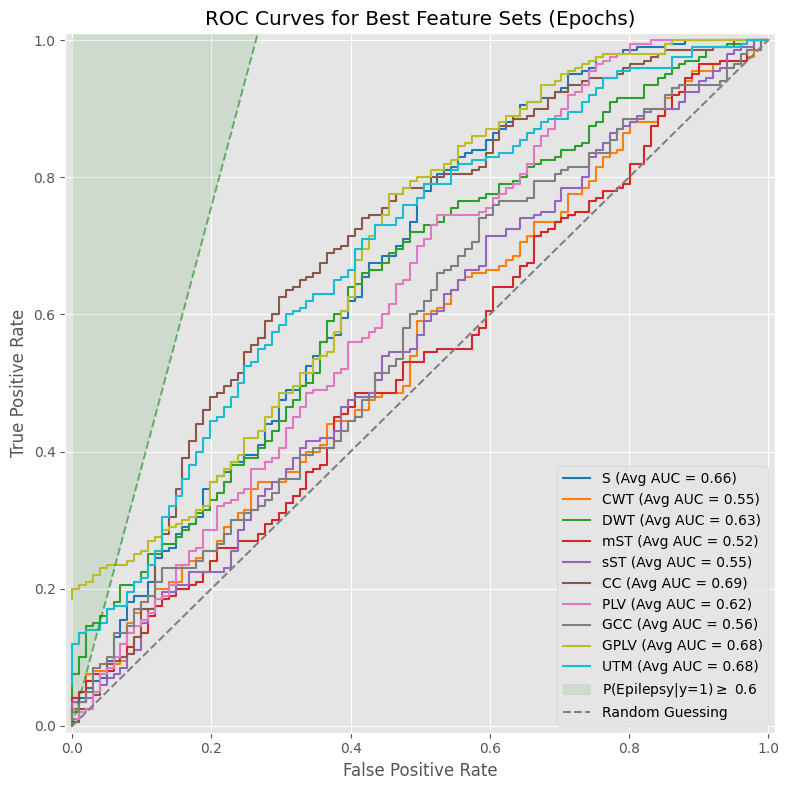


COMPREHENSIVE METRICS FOR EPOCHS


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

Feature      ACCURACY           BAC         BAC80      F1_SCORE     PRECISION        RECALL           AUC         AUPRC            AP
      S 0.718 ± 0.003 0.503 ± 0.006 0.638 ± 0.014 0.010 ± 0.022 0.200 ± 0.447 0.005 ± 0.011 0.654 ± 0.017 0.374 ± 0.013 0.388 ± 0.014
    CWT 0.370 ± 0.103 0.498 ± 0.015 0.544 ± 0.032 0.407 ± 0.055 0.280 ± 0.010 0.795 ± 0.282 0.543 ± 0.066 0.331 ± 0.052 0.347 ± 0.059
    DWT 0.716 ± 0.000 0.500 ± 0.000 0.569 ± 0.036 0.000 ± 0.000 0.000 ± 0.000 0.000 ± 0.000 0.628 ± 0.023 0.404 ± 0.020 0.418 ± 0.020
    mST 0.597 ± 0.157 0.524 ± 0.020 0.536 ± 0.068 0.250 ± 0.194 0.295 ± 0.184 0.355 ± 0.390 0.518 ± 0.077 0.319 ± 0.064 0.334 ± 0.068
    sST 0.485 ± 0.186 0.497 ± 0.022 0.556 ± 0.054 0.317 ± 0.117 0.288 ± 0.054 0.525 ± 0.436 0.546 ± 0.055 0.323 ± 0.045 0.338 ± 0.043
     CC 0.674 ± 0.007 0.511 ± 0.005 0.652 ± 0.019 0.190 ± 0.014 0.322 ± 0.017 0.135 ± 0.014 0.684 ± 0.017 0.391 ± 0.020 0.404 ± 0.020
    PLV 0.716 ± 0.000 0.500 ± 0.000 0.583 ± 0.018 0.000 ± 0.00

In [9]:
'''SPECTRAL	bipolar	1	kurt	(1166,2186,503,286,3447)
UTM	laplacian	2	kurt	(1866,1219,4289,4140,4881)
CC	car	5	mean	(723,181,2038,3,323)
GCC	laplacian	10	std	(1582,4579,310,784,2179)
PLV	car 	5	std	(963,4509,2624,3468,3584)
GPLV	laplacian	2	median	(2377,1830,3856,2221,3553)
CWT	laplacian	10	std	(3527,1823,1087,2833,3742)
DWT	bipolar	2	kurt	(2722,2632,1460,2850,2154)
SST	car	5	kurt	(2553,121,3846,3812,4199)
MST	laplacian	5	kurt	(485,3452,2442,2954,1627)'''

best_runs_epochs={
    'spectral' : ('BipolarDB', 1, 'kurt', (1166, 2186, 503, 286, 3447)),
    'utm' : ('Laplacian', 2, 'kurt', (1866, 1219, 4289, 4140, 4881)),
    'cc' : ('CAR', 5, 'mean', (723, 181, 2038, 3, 323)),
    'gcc' : ('Laplacian', 10, 'std', (1582, 4579, 310, 784, 2179)),
    'plv' : ('CAR', 5, 'std', (963, 4509, 2624, 3468, 3584)),
    'gplv' : ('Laplacian', 2, 'median', (2377, 1830, 3856, 2221, 3553)),
    'cwt' : ('Laplacian', 10, 'std', (3527, 1823, 1087, 2833, 3742)),
    'dwt' : ('BipolarDB', 2, 'kurt', (2722, 2632, 1460, 2850, 2154)),
    'sst' : ('CAR', 5, 'kurt', (2553, 121, 3846, 3812, 4199)),
    'mst' : ('Laplacian', 5, 'kurt', (485, 3452, 2442, 2954, 1627))
}

plt.figure(figsize=(8,8))
for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_epochs[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=True)
    roc_data = []
    preds=pd.DataFrame(columns=['y_true','y_prob'])

    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
    
        y_true = df['y_true'].values
        y_pred = df['y_prob'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)

    fpr, tpr = vertical_avg_roc(roc_data)

    # pooled ROC curve
    y_true = np.array(preds['y_true'].values).astype(np.float64)
    y_pred = np.array(preds['y_prob'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)

    auc_avg= metrics.auc(fpr, tpr)
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}, Average AUC: {auc_avg:.2f}')

    plot_avg=True

    if plot_avg:
        plt.step(fpr, tpr, label=f'{featnames[feature_type]} (Avg AUC = {auc_avg:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    else:
        plt.step(fpr_pooled, tpr_pooled, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')

slope = compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6)
# plot a line with this slope, limit the y axis to [0, 1]
plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
#fill above the line
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$ \geq $ 0.6')


plt.title('ROC Curves for Best Feature Sets (Epochs)')
plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute comprehensive metrics for all feature types (epochs)
print("\n" + "="*80)
print("COMPREHENSIVE METRICS FOR EPOCHS")
print("="*80)

df_metrics_epochs = create_metrics_summary_table(feat_types, best_runs_epochs, DATADIR, epochs=True)

# Compute mean and std for each feature type
metrics_cols = ['accuracy', 'bac', 'bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc', 'AP']
summary_stats_epochs = df_metrics_epochs.groupby('feature_type')[metrics_cols].agg(['mean', 'std']).round(3)

# Create a formatted table with mean ± std
formatted_table_epochs = pd.DataFrame()
formatted_table_epochs['Feature'] = [featnames[ft] for ft in feat_types]

for metric in metrics_cols:
    mean_vals = summary_stats_epochs[(metric, 'mean')]
    std_vals = summary_stats_epochs[(metric, 'std')]
    formatted_table_epochs[metric.upper()] = [f"{mean_vals[ft]:.3f} ± {std_vals[ft]:.3f}" for ft in feat_types]

print(formatted_table_epochs.to_string(index=False))

# Also print a cleaner version with separate mean and std tables
print("\n" + "="*80)
print("MEAN VALUES (EPOCHS)")
print("="*80)
mean_table_epochs = pd.DataFrame()
mean_table_epochs['Feature'] = [featnames[ft] for ft in feat_types]
for metric in metrics_cols:
    mean_table_epochs[metric.upper()] = [summary_stats_epochs[(metric, 'mean')][ft] for ft in feat_types]
print(mean_table_epochs.to_string(index=False))

print("\n" + "="*80)
print("STANDARD DEVIATIONS (EPOCHS)")
print("="*80)
std_table_epochs = pd.DataFrame()
std_table_epochs['Feature'] = [featnames[ft] for ft in feat_types]
for metric in metrics_cols:
    std_table_epochs[metric.upper()] = [summary_stats_epochs[(metric, 'std')][ft] for ft in feat_types]
print(std_table_epochs.to_string(index=False))

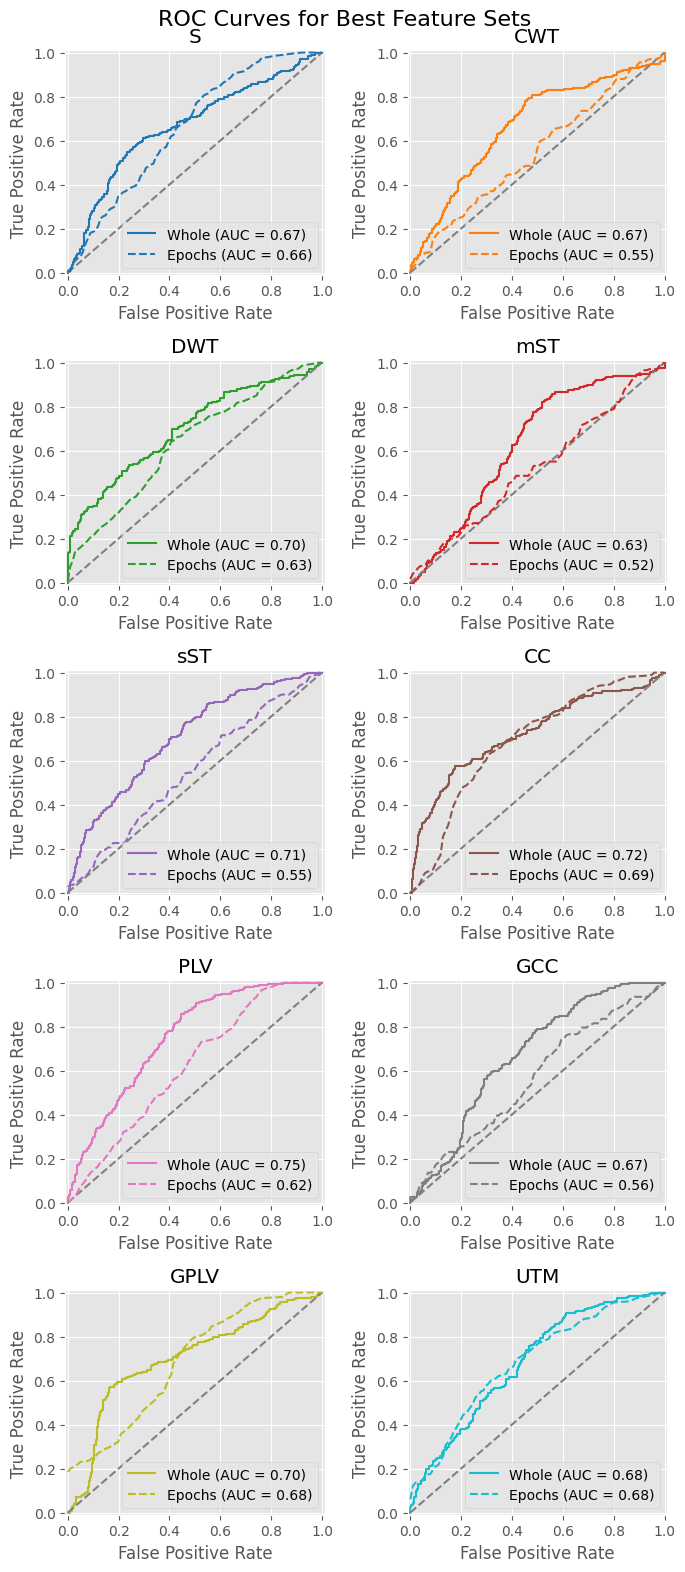

In [10]:
# 5x2 subplots with the ROC curves for each feature type comparing the epochs data with and without IEDs
fig, axs = plt.subplots(5, 2, figsize=(7, 16))
axs = axs.flatten()
for i, feature_type in enumerate(feat_types):
    montage, length, combiner, seeds = best_runs_whole[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=False)
    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
        y_true = df['y_tests'].values
        y_pred = df['y_scores'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)

    # pooled ROC curve
    y_true = np.array(preds['y_tests'].values).astype(np.float64)
    y_pred = np.array(preds['y_scores'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)

    axs[i].plot(fpr_pooled, tpr_pooled, label=f'Whole (AUC = {auc_pooled:.2f})', color=colors[i], linestyle='solid')
    axs[i].set_title(f'{featnames[feature_type]}')
    axs[i].plot([0, 1], [0, 1], '--', label='', color='gray')
    axs[i].set_xlabel('False Positive Rate')
    axs[i].set_ylabel('True Positive Rate')
    axs[i].set_xlim([-0.01, 1.01])
    axs[i].set_ylim([-0.01, 1.01])
    axs[i].legend(loc='lower right')
    axs[i].grid(True)
# Now for the epochs data
for i, feature_type in enumerate(feat_types):
    montage, length, combiner, seeds = best_runs_epochs[feature_type]

    predictions_files = get_predictions_files(DATADIR, montage, feature_type, length, combiner, seeds, epochs=True)
    roc_data = []
    preds=pd.DataFrame(columns=['y_true','y_prob'])

    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR, file))
    
        y_true = df['y_true'].values
        y_pred = df['y_prob'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)

    fpr, tpr = vertical_avg_roc(roc_data)

    # pooled ROC curve
    y_true = np.array(preds['y_true'].values).astype(np.float64)
    y_pred = np.array(preds['y_prob'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)

    auc_avg= metrics.auc(fpr, tpr)
    axs[i].plot(fpr, tpr, label=f'Epochs (AUC = {auc_avg:.2f})', color=colors[i], linestyle='dashed')
    axs[i].legend(loc='lower right')

plt.suptitle('ROC Curves for Best Feature Sets', fontsize=16)
plt.tight_layout()
plt.show()